In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use("ggplot")

# Load dataset
df = pd.read_csv(r"C:\Data Science\data sets\HREmployeeAttrition.csv")

# View first rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# Check dataset shape (rows, columns)
df.shape

(1470, 35)

In [3]:
# Check column names
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [4]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**Exploratory Data Analysis**

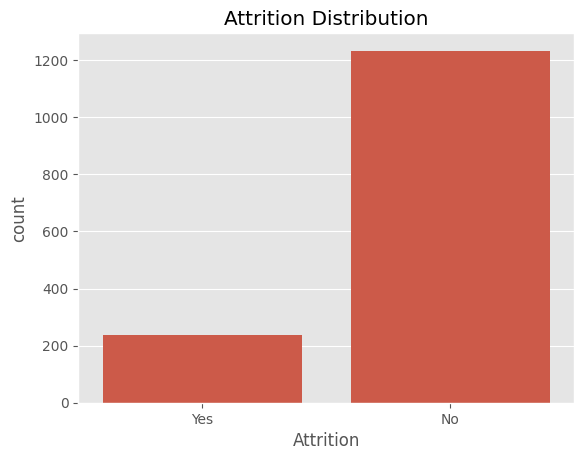

In [6]:
# Target variable distribution
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Distribution")
plt.show()

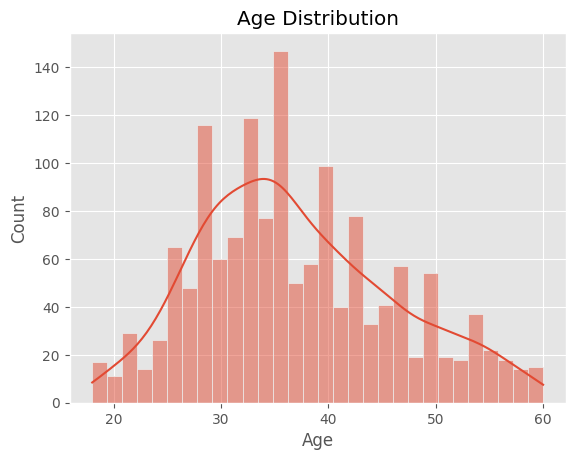

In [7]:
# Age distribution
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

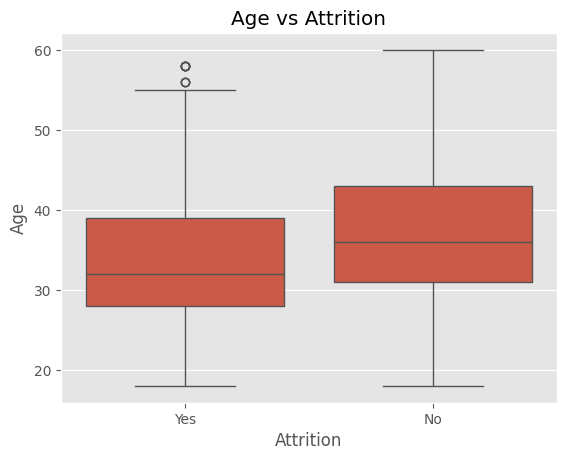

In [8]:
# Age vs Attrition
sns.boxplot(x="Attrition", y="Age", data=df)
plt.title("Age vs Attrition")
plt.show()

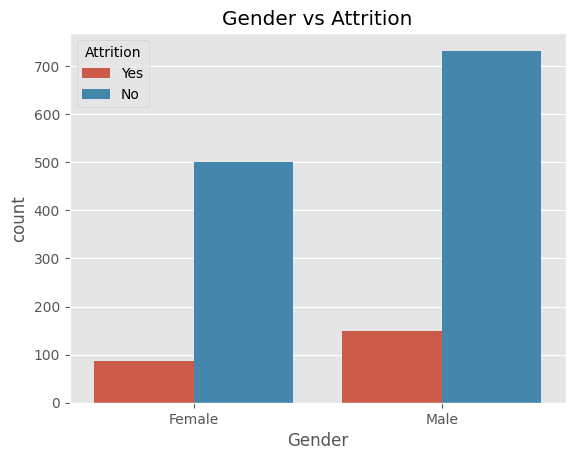

In [9]:
# Gender vs Attrition
sns.countplot(x="Gender", hue="Attrition", data=df)
plt.title("Gender vs Attrition")
plt.show()

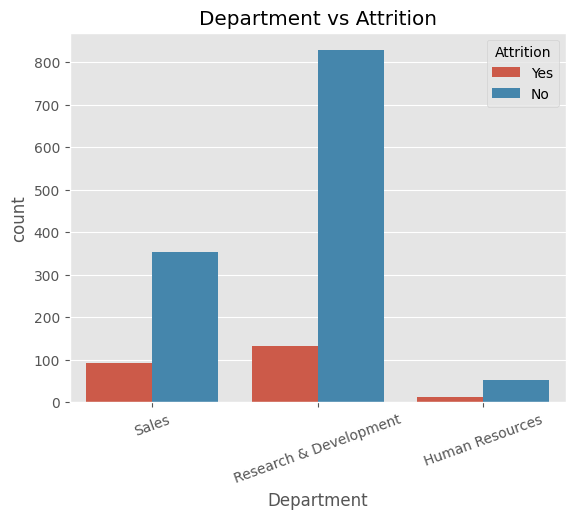

In [10]:
# Department vs Attrition
sns.countplot(x="Department", hue="Attrition", data=df)
plt.xticks(rotation=20)
plt.title("Department vs Attrition")
plt.show()

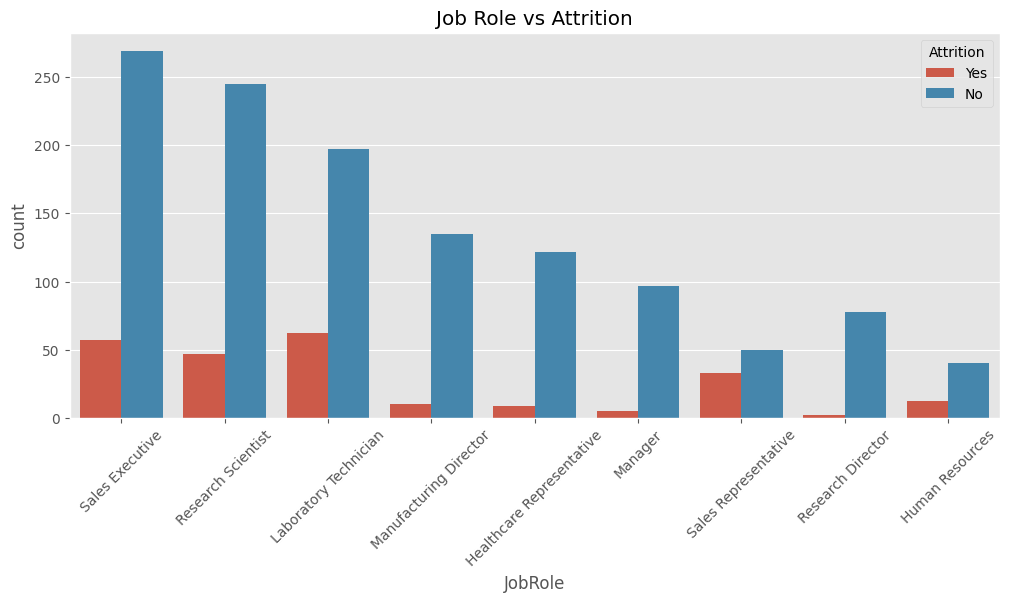

In [11]:
# Job Role vs Attrition
plt.figure(figsize=(12,5))
sns.countplot(x="JobRole", hue="Attrition", data=df)
plt.xticks(rotation=45)
plt.title("Job Role vs Attrition")
plt.show()

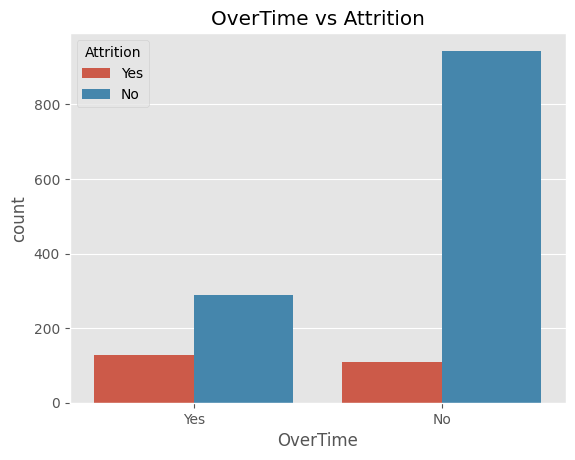

In [12]:
# Overtime vs Attrition
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("OverTime vs Attrition")
plt.show()

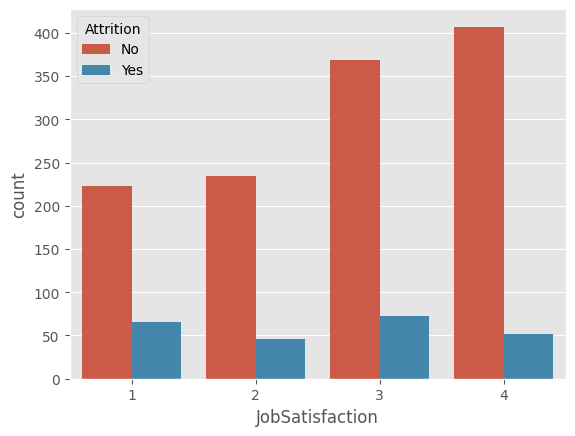

In [13]:
# Job Satisfaction vs Attrition
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)
plt.show()

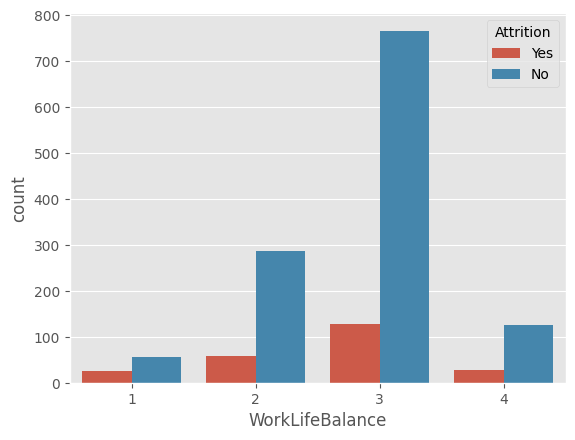

In [14]:
# Work Life Balance vs Attrition
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df)
plt.show()

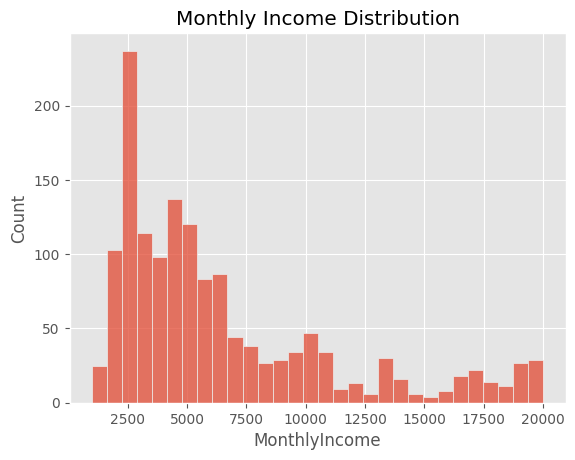

In [15]:
# Monthly income distribution
sns.histplot(df["MonthlyIncome"], bins=30)
plt.title("Monthly Income Distribution")
plt.show()

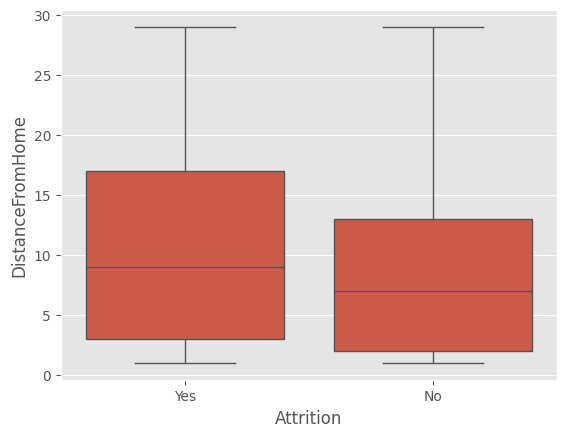

In [16]:
# Distance from home vs attrition
sns.boxplot(x="Attrition", y="DistanceFromHome", data=df)
plt.show()

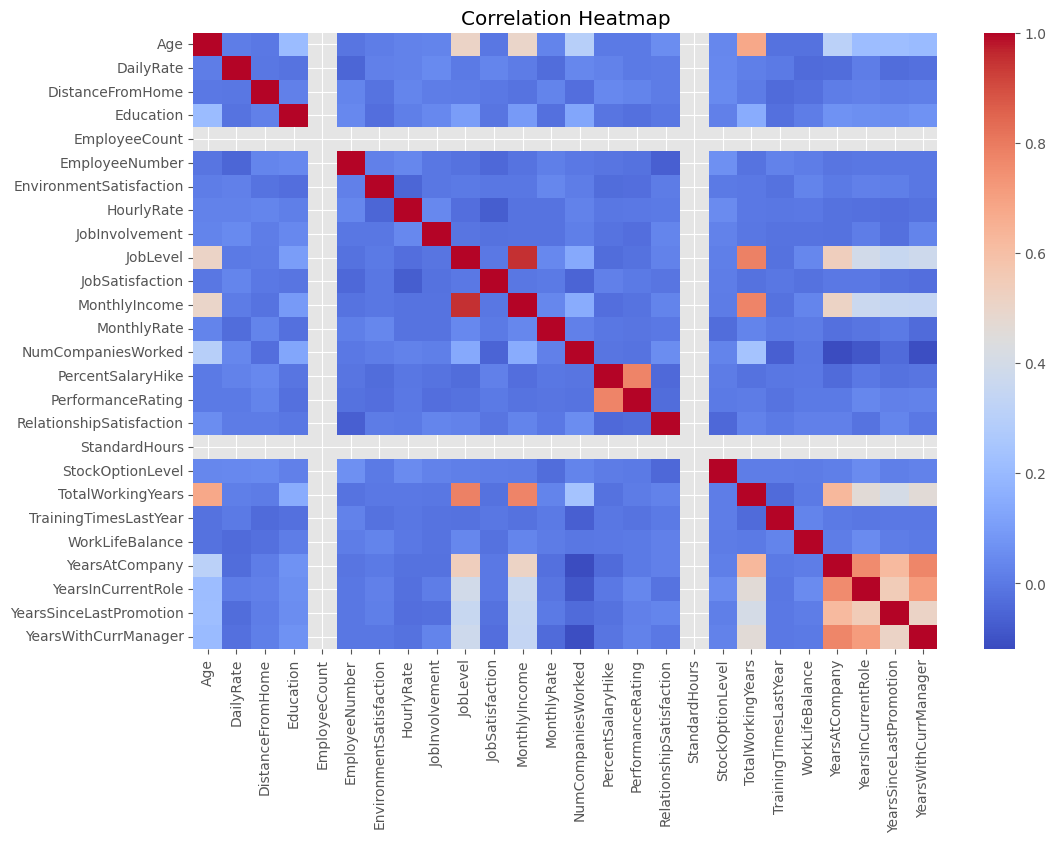

In [17]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

***Feature Engineering***

In [18]:
# Drop irrelevant columns
df.drop(["EmployeeNumber","EmployeeCount","StandardHours","Over18"],
        axis=1, inplace=True, errors="ignore")

In [19]:
# Convert Attrition target variable to numeric
df["Attrition"] = df["Attrition"].map({"Yes":1,"No":0})

In [20]:
# Create additional engineered features
df["IncomePerYearAtCompany"] = df["MonthlyIncome"]/(df["YearsAtCompany"]+1)
df["PromotionGap"] = df["YearsSinceLastPromotion"]/(df["YearsAtCompany"]+1)
df["OverTimeFlag"] = df["OverTime"].map({"Yes":1,"No":0})

In [21]:
# Convert categorical features to numeric using one hot encoding
df = pd.get_dummies(df, drop_first=True)

***Feature Selection***

In [22]:
# Separate features and target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [23]:
# Remove highly correlated features
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

X = X.drop(columns=to_drop)

***Train Test Split***

In [24]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

***Handle Class Imbalance (SMOTE)***

In [25]:
# Handle Class Imbalance
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

***Model Pipeline***

In [26]:
# ML Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

pipeline_dt = Pipeline([
    ("model", DecisionTreeClassifier())
])

pipeline_rf = Pipeline([
    ("model", RandomForestClassifier())
])

***Scaling Comparison***

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standard Scaler
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

# MinMax Scaler
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

***Baseline Model Training***

In [28]:
# Initialize models
log_model = LogisticRegression(max_iter=1000)
knn_model = KNeighborsClassifier()
dt_model = DecisionTreeClassifier()
rf_model = RandomForestClassifier()

In [29]:
# Train models
log_model.fit(X_train_std,y_train)
knn_model.fit(X_train_std,y_train)
dt_model.fit(X_train,y_train)
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

***Model Evaluation***

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report , roc_auc_score


In [31]:
# Store model results
results=[]

In [32]:
# Logistic Regression
pred=log_model.predict(X_test_std)
prob=log_model.predict_proba(X_test_std)[:,1]

results.append(["Logistic",accuracy_score(y_test,pred),
precision_score(y_test,pred),recall_score(y_test,pred),
f1_score(y_test,pred),roc_auc_score(y_test,prob)])

In [33]:
# KNN
pred=knn_model.predict(X_test_std)
prob=knn_model.predict_proba(X_test_std)[:,1]

results.append(["KNN",accuracy_score(y_test,pred),
precision_score(y_test,pred),recall_score(y_test,pred),
f1_score(y_test,pred),roc_auc_score(y_test,prob)])

In [34]:
# Decision Tree
pred=dt_model.predict(X_test)
prob=dt_model.predict_proba(X_test)[:,1]

results.append(["DecisionTree",accuracy_score(y_test,pred),
precision_score(y_test,pred),recall_score(y_test,pred),
f1_score(y_test,pred),roc_auc_score(y_test,prob)])

In [35]:
# Random Forest
pred=rf_model.predict(X_test)
prob=rf_model.predict_proba(X_test)[:,1]

results.append(["RandomForest",accuracy_score(y_test,pred),
precision_score(y_test,pred),recall_score(y_test,pred),
f1_score(y_test,pred),roc_auc_score(y_test,prob)])

In [36]:
# Convert results to dataframe
baseline_results=pd.DataFrame(results,
columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC"])
baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic,0.850340,0.542857,0.404255,0.463415,0.821173
1,KNN,0.802721,0.342857,0.255319,0.292683,0.667672
2,DecisionTree,0.734694,0.253968,0.340426,0.290909,0.575071
3,RandomForest,0.823129,0.407407,0.234043,0.297297,0.754199


***Checking OverFitting***

In [37]:
models = {
    "Logistic Regression": pipeline_lr,
    "KNN": pipeline_knn,
    "Decision Tree": pipeline_dt,
    "Random Forest": pipeline_rf
}

for name, model in models.items():
    
    print("\n")
    print("="*70)
    print(f"MODEL : {name}")
    print("="*70)
    
    model.fit(X_train, y_train)
    
    # ===================== TRAINING DATA =====================
    print("******************** TRAINING DATA ********************")
    
    y_pred_train = model.predict(X_train)
    
    print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
    print("*"*50)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    train_prec = precision_score(y_train, y_pred_train)
    train_rec = recall_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    
    print("Accuracy :", train_acc)
    print("Precision:", train_prec)
    print("Recall   :", train_rec)
    print("F1 Score :", train_f1)
    
    print("*"*50)
    print("Classification Report:\n", classification_report(y_train, y_pred_train))
    
    # ===================== TESTING DATA =====================
    print("******************** TESTING DATA ********************")
    
    y_pred_test = model.predict(X_test)
    
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
    print("*"*50)
    
    test_acc = accuracy_score(y_test, y_pred_test)
    test_prec = precision_score(y_test, y_pred_test)
    test_rec = recall_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    
    print("Accuracy :", test_acc)
    print("Precision:", test_prec)
    print("Recall   :", test_rec)
    print("F1 Score :", test_f1)
    
    print("*"*50)
    print("Classification Report:\n", classification_report(y_test, y_pred_test))
    
    # ===================== OVERFITTING CHECK =====================
    
    print("******************** OVERFITTING CHECK ********************")
    
    diff_acc = train_acc - test_acc
    diff_f1 = train_f1 - test_f1
    
    print("Accuracy Difference:", diff_acc)
    print("F1 Score Difference:", diff_f1)
    
    if diff_acc > 0.05 or diff_f1 > 0.05:
        print("Model may be OVERFITTING")
    elif diff_acc < -0.05:
        print("Model may be UNDERFITTING")
    else:
        print(" Model generalizes well")
    
    print("="*70)



MODEL : Logistic Regression
******************** TRAINING DATA ********************
Confusion Matrix:
 [[945  41]
 [102 884]]
**************************************************
Accuracy : 0.9274847870182555
Precision: 0.9556756756756757
Recall   : 0.896551724137931
F1 Score : 0.9251700680272109
**************************************************
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93       986
           1       0.96      0.90      0.93       986

    accuracy                           0.93      1972
   macro avg       0.93      0.93      0.93      1972
weighted avg       0.93      0.93      0.93      1972

******************** TESTING DATA ********************
Confusion Matrix:
 [[231  16]
 [ 28  19]]
**************************************************
Accuracy : 0.8503401360544217
Precision: 0.5428571428571428
Recall   : 0.40425531914893614
F1 Score : 0.4634146341463415
*******************************

***Cross Validation***

In [38]:
from sklearn.model_selection import cross_val_score


for name, model in models.items():
    
    print("\n" + "="*60)
    print(f"MODEL : {name}")
    print("="*60)
    
    # Train model
    model.fit(X_train, y_train)
    
    # Test prediction
    y_pred_test = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    # Cross validation
    cv_scores = cross_val_score(model, X, y, cv=5)
    cv_score = cv_scores.mean()
    
    print("Test Accuracy :", round(test_accuracy,4))
    print("CV Score      :", round(cv_score,4))
    
    difference = abs(test_accuracy - cv_score)
    
    print("Difference    :", round(difference,4))
    
    # Interpretation
    if difference <= 0.02:
        print("Excellent generalization")
    elif difference <= 0.05:
        print("Model generalizes well")
    elif difference <= 0.10:
        print("Slight overfitting possible")
    else:
        print("Model likely overfitting")


MODEL : Logistic Regression
Test Accuracy : 0.8503
CV Score      : 0.8803
Difference    : 0.0299
Model generalizes well

MODEL : KNN
Test Accuracy : 0.8027
CV Score      : 0.8463
Difference    : 0.0435
Model generalizes well

MODEL : Decision Tree
Test Accuracy : 0.7177
CV Score      : 0.7905
Difference    : 0.0728
Slight overfitting possible

MODEL : Random Forest
Test Accuracy : 0.8265
CV Score      : 0.8565
Difference    : 0.0299
Model generalizes well


***Hyperparameter Tuning***

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [40]:
# Define parameter grid for Random Forest
params={
"n_estimators":[100,200],
"max_depth":[5,10,None],
"min_samples_split":[2,5]
}

In [41]:


# GridSearchCV to tune model
grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid=params,
    cv=5,
    scoring="recall"
)

# Fit model
grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_

In [42]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


#check best parameters

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
0.8862995436599498


***ROC-AUC Curve***

In [43]:
from sklearn.metrics import roc_curve

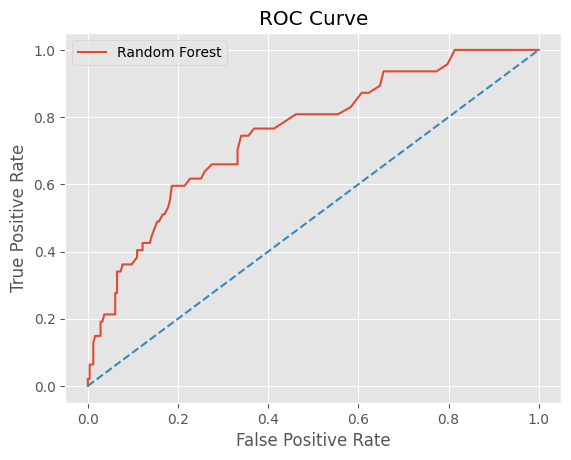

In [44]:
# Predict probabilities
y_prob=best_rf.predict_proba(X_test)[:,1]

# Calculate ROC curve
fpr,tpr,_=roc_curve(y_test,y_prob)

# Plot ROC curve
plt.plot(fpr,tpr,label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

***Confusion Matrix***

confusion matrix is [[232  15]
 [ 36  11]]


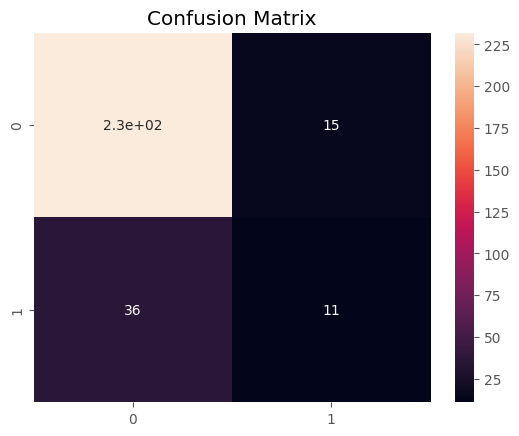

In [45]:
from sklearn.metrics import confusion_matrix
# Predict classes
pred=best_rf.predict(X_test)

cfn_matrix= confusion_matrix(y_test,pred)
print("confusion matrix is",cfn_matrix)
# Plot confusion matrix
sns.heatmap(confusion_matrix(y_test,pred),annot=True)

plt.title("Confusion Matrix")

plt.show()

***K-Means Segmentation***

In [46]:
# Select features for clustering
cluster_features=["Age","MonthlyIncome","DistanceFromHome","YearsAtCompany","TotalWorkingYears"]

cluster_data=df[cluster_features]

In [47]:
# Scale data for clustering
scaler=StandardScaler()

cluster_scaled=scaler.fit_transform(cluster_data)

***Elbow Curve***

In [48]:
from sklearn.cluster import KMeans

In [49]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(n_clusters=i,random_state=42)

    kmeans.fit(cluster_scaled)

    wcss.append(kmeans.inertia_)

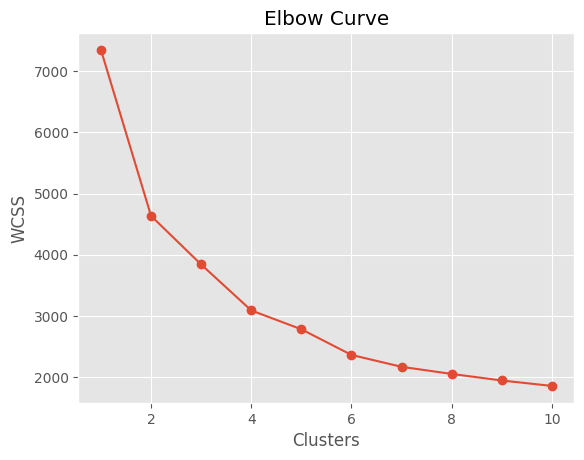

In [50]:
plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Curve")

plt.show()

***Final Clustering***

In [51]:
kmeans=KMeans(n_clusters=4,random_state=42)

df["Cluster"]=kmeans.fit_predict(cluster_scaled)

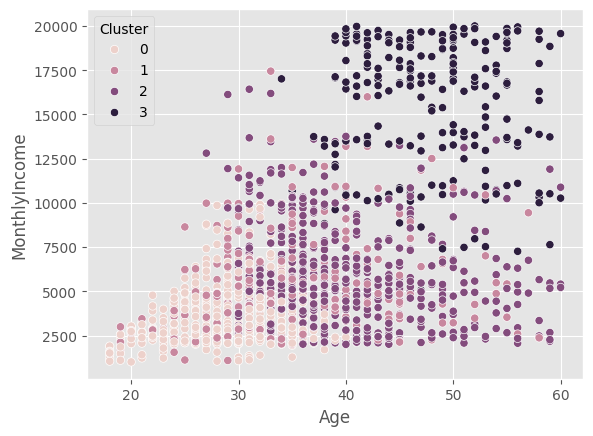

In [52]:
sns.scatterplot(
x=df["Age"],
y=df["MonthlyIncome"],
hue=df["Cluster"]
)

plt.show()

***Baseline vs Tuned Results***

In [53]:
# Tuned model evaluation
pred=best_rf.predict(X_test)
prob=best_rf.predict_proba(X_test)[:,1]

tuned_results=pd.DataFrame([[
"RandomForest Tuned",
accuracy_score(y_test,pred),
precision_score(y_test,pred),
recall_score(y_test,pred),
f1_score(y_test,pred),
roc_auc_score(y_test,prob)
]],columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC"])

In [54]:
final_results=pd.concat([baseline_results,tuned_results])

final_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic,0.850340,0.542857,0.404255,0.463415,0.821173
1,KNN,0.802721,0.342857,0.255319,0.292683,0.667672
2,DecisionTree,0.734694,0.253968,0.340426,0.290909,0.575071
3,RandomForest,0.823129,0.407407,0.234043,0.297297,0.754199
0,RandomForest Tuned,0.826531,0.423077,0.234043,0.301370,0.751787


***Feature Importance***

In [55]:
# Calculate feature importance
feature_importance=pd.Series(
best_rf.feature_importances_,
index=X.columns
)

feature_importance=feature_importance.sort_values(ascending=False)

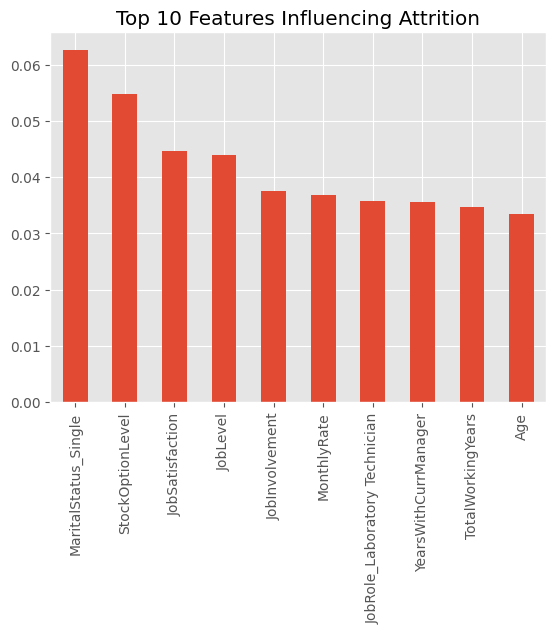

In [56]:
 # Plot feature importance
feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Features Influencing Attrition")

plt.show()